# Import Packages

In [1]:
import pandas as pd
import numpy as np
import os
from datetime import datetime
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
# Models
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor


pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 1000)

# Configuration

In [10]:
# General configuration
data_path = "./"
log_path = "./logs"
model_name = "RandomForestRegressor"
feature_handling = "onehot encoding、building age、normalize、gaussion basis function"

# Load Dataset

In [11]:
X_train_df = pd.read_csv(os.path.join(data_path, 'X_train.csv'), index_col=0)
y_train_df = pd.read_csv(os.path.join(data_path, 'y_train.csv'), index_col=0)
X_test_df = pd.read_csv(os.path.join(data_path, 'X_test.csv'), index_col=0)

print(f"X_train shape: {X_train_df.shape}")
print(f"y_train shape: {y_train_df.shape}")
print(f"X_test shape: {X_test_df.shape}")

X_train shape: (9460, 41)
y_train shape: (9460, 1)
X_test shape: (2366, 41)


# Feature Engineering

In [12]:
X_train_df['購物場所'] = np.mean(X_train_df[['大賣場', '超市', '百貨公司']], axis=1)
X_test_df['購物場所'] = np.mean(X_test_df[['大賣場', '超市', '百貨公司']], axis=1)

X_train_df = X_train_df.drop(['托兒所', '國中', '高中職', '大學'], axis=1)
X_test_df = X_test_df.drop(['托兒所', '國中', '高中職', '大學'], axis=1)

X_train_df = X_train_df.drop(['大賣場', '超市', '百貨公司'], axis=1)
X_test_df = X_test_df.drop(['大賣場', '超市', '百貨公司'], axis=1)

In [6]:
X_train_df.head()

,鄉鎮市區,交易標的,路名,土地移轉總面積平方公尺,都市土地使用分區,土地數,建物數,車位數,移轉層次,移轉層次項目,總樓層數,建物型態,主要用途,主要建材,建築完成年月,建物移轉總面積平方公尺,建物現況格局-房,建物現況格局-廳,建物現況格局-衛,建物現況格局-隔間,有無管理組織,交易年,交易日,交易月,地鐵站,超商,公園,國小,金融機構,醫院,警察局,消防局,縱坐標,橫坐標,購物場所
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,文山區,房地(土地+建物)+車位,興隆路三段,27.75,住,1.0,1.0,1.0,1,無,7.0,華廈(10層含以下有電梯),見其他登記事項,鋼筋混凝土造,2019-10-16,133.43,3,2,2,有,有,2019,31,8,1.0,7.0,2.0,20.0,15.0,20.0,20.0,16.0,24.957269,121.588026,13.333333
1,中正區,房地(土地+建物),金山南路一段,9.57,第三種住宅區,1.0,1.0,0.0,5,無,6.0,華廈(10層含以下有電梯),住家用,鋼筋混凝土造,1997-08-20,40.34,1,1,1,有,有,2021,8,1,1.0,12.0,8.0,20.0,20.0,20.0,20.0,20.0,24.997141,121.558262,17.666667
2,文山區,房地(土地+建物),秀明路一段,9.51,住,1.0,1.0,0.0,1,無,7.0,套房(1房1廳1衛),住家用,鋼筋混凝土造,2009-05-13,70.61,1,1,1,有,有,2020,29,4,0.0,6.0,7.0,20.0,15.0,18.0,20.0,13.0,24.953906,121.601050,12.333333
3,內湖區,房地(土地+建物)+車位,康樂街,23.67,第三種住宅區,1.0,1.0,1.0,10,無,15.0,住宅大樓(11層含以上有電梯),見其他登記事項,鋼筋混凝土造,2009-04-24,143.83,3,2,2,有,有,2019,5,6,1.0,12.0,14.0,20.0,19.0,20.0,20.0,15.0,25.008046,121.557424,15.000000
4,北投區,房地(土地+建物),公路,22.50,第三種住宅區,1.0,1.0,0.0,2,無,5.0,公寓(5樓含以下無電梯),住家用,鋼筋混凝土造,1973-02-15,83.73,2,1,1,有,無,2021,8,4,2.0,4.0,13.0,20.0,19.0,20.0,18.0,13.0,24.986825,121.557424,15.333333


# Visualize data

<Axes: xlabel='橫坐標', ylabel='縱坐標'>

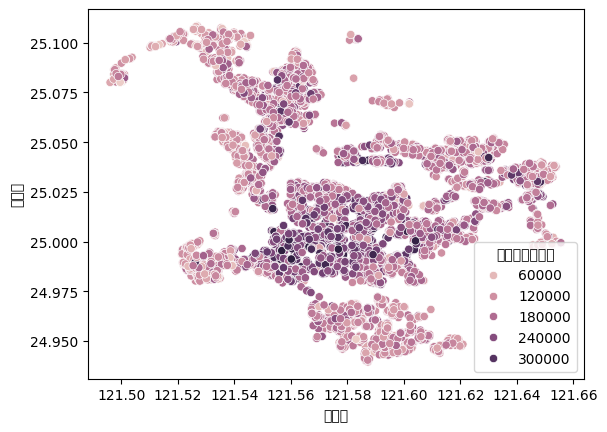

In [13]:
sns.scatterplot(x=X_train_df['橫坐標'], y=X_train_df['縱坐標'], hue=y_train_df['單價元平方公尺'])

# Utility Functions

In [14]:
# 將建築完成年月更改成建築年齡
def make_building_age_feature(df: pd.DataFrame):
    tranaction_year = df['交易年'].apply(lambda x: datetime.strptime(str(x), "%Y").year)
    # Year of construction
    df['建築完成年月'] = df['建築完成年月'].apply(lambda x: datetime.strptime(x, "%Y-%m-%d").year)
    # Building age
    df['交易時屋齡'] = tranaction_year - df['建築完成年月']

    return df.drop(columns=['建築完成年月'])

# 處理類別資料
def deal_with_catagorical_data(df, encoder, categorical_features, numerical_features) -> pd.DataFrame:
    catagorical_array: np.ndarray = encoder.transform(df[categorical_features]).toarray()
    feature_names = encoder.get_feature_names_out(categorical_features)

    numerical_array = df[numerical_features].to_numpy()

    merged_array = np.concatenate((numerical_array, catagorical_array), axis=1)
    merged_df = pd.DataFrame(merged_array, columns=np.concatenate((numerical_features, feature_names)))

    return merged_df


# Gaussian Basis Function
def gaussion_basis(df: pd.DataFrame) -> pd.DataFrame:
    K = 3
    mu_x_all = []
    mu_y_all = []
    std_x_all = []
    std_y_all = []

    # 取出該城市的橫(縱)坐標
    coord_x_list = df['橫坐標'].to_numpy()
    coord_y_list = df['縱坐標'].to_numpy()

    # 取出該城市橫(縱)坐標的最大最小值
    coord_x_min = np.min(coord_x_list)
    coord_x_max = np.max(coord_x_list)
    coord_y_min = np.min(coord_y_list)
    coord_y_max = np.max(coord_y_list)

    # 在最大與最小值之間分成四等分，所以會是 3*3 的網格
    grid_x = np.linspace(coord_x_min, coord_x_max, K+1)
    grid_y = np.linspace(coord_y_min, coord_y_max, K+1)

    # 遍歷每個網格
    for i in range(K):
        for j in range(K):
            x1 = grid_x[i]
            x2 = grid_x[i+1]
            y1 = grid_y[j]
            y2 = grid_y[j+1]

            # 取出該網格的橫(縱)坐標
            in_grid_x = (x1 <= coord_x_list) * (coord_x_list < x2)
            in_grid_y = (y1 <= coord_y_list) * (coord_y_list < y2)
            # 同時在 x範圍內和 y 範圍內的資料
            in_grid = in_grid_x * in_grid_y

            num_points = np.sum(in_grid)
            if num_points < 20:
                continue

            # 計算該網格內的中心點，也就是該網格的 anchor，以及標準差
            mu_x = np.mean(coord_x_list[in_grid])
            mu_y = np.mean(coord_y_list[in_grid])
            std_x = np.std(coord_x_list[in_grid])
            std_y = np.std(coord_y_list[in_grid])

            mu_x_all.append(mu_x)
            mu_y_all.append(mu_y)
            std_x_all.append(std_x)
            std_y_all.append(std_y)

    anchor_num = len(mu_x_all)

    gf_feature_all = np.zeros((len(coord_x_list), anchor_num))

    for i in range(anchor_num):
        mu_x = mu_x_all[i]
        mu_y = mu_y_all[i]
        std_x = std_x_all[i]
        std_y = std_y_all[i]

        gf_feature_all[:, i] = np.exp(-((coord_x_list - mu_x)**2 / (2 * std_x**2) + (coord_y_list - mu_y)**2 / (2 * std_y**2)))

    X_train_gf: np.ndarray = np.hstack((df.to_numpy(), gf_feature_all))
    
    gf_feature_column_names = [f'GF_{i}' for i in range(gf_feature_all.shape[1])]
    X_train_gf: pd.DataFrame = pd.DataFrame(X_train_gf, columns=np.concatenate((df.columns, gf_feature_column_names)))

    return X_train_gf

# Feature Selection

## Correlation

In [15]:
def feature_selection(X_train: pd.DataFrame, y_train, encoder, standardize, threshold=0.01):
    # Feature Engineering
    ## 計算屋齡
    X_train_kf: pd.DataFrame = make_building_age_feature(X_train)

    ## 處理類別資料
    categorical_features = X_train_kf.select_dtypes(include=['object']).columns
    numerical_features = X_train_kf.columns[~X_train_kf.columns.isin(categorical_features)]

    encoder.fit(X_train_kf[categorical_features])

    X_train_kf: pd.DataFrame = deal_with_catagorical_data(X_train_kf, encoder, categorical_features, numerical_features)

    ## Gaussian Basis Function
    X_train_kf: pd.DataFrame = gaussion_basis(X_train_kf)

    # Feature Selection
    train_corr = X_train_kf.corrwith(y_train['單價元平方公尺'], axis=0)
    train_corr = abs(train_corr)

    selected_features = train_corr[train_corr > threshold].index
    
    return selected_features

encoder = OneHotEncoder(handle_unknown='ignore')
standardize = StandardScaler()

X_train = X_train_df.copy(deep=True)
y_train = y_train_df.copy(deep=True)

selected_features = feature_selection(X_train, y_train, encoder, standardize)
print(f"Selected features shape: {selected_features.shape}")

Selected features shape: (518,)


# Model

In [16]:
model1 = RandomForestRegressor(n_estimators=300, min_samples_split=3, random_state=1001, n_jobs=-1)
model2 = Ridge(alpha=0.1, random_state=1001)

model = StackingRegressor(
    estimators=[
        ('ridge', model2),
        ('rf', model1),
    ],
    final_estimator=model2
)

# Training

In [17]:
def training(X_train: pd.DataFrame, y_train: pd.DataFrame, model, encoder, standardize, selected_features):
    # K-fold cross validation
    kf = KFold(n_splits=5, shuffle=True, random_state=1001)
    rmse_list = []

    for index, (train_indexes, valid_indexes) in enumerate(kf.split(X_train)):
        print(f"Fold: {index+1}")
        X_train_kf, y_train_kf = X_train.iloc[train_indexes], y_train.iloc[train_indexes]
        X_valid_kf, y_valid_kf = X_train.iloc[valid_indexes], y_train.iloc[valid_indexes]
        # Feature Engineering
        ## 計算屋齡
        X_train_kf: pd.DataFrame = make_building_age_feature(X_train_kf)
        X_valid_kf: pd.DataFrame = make_building_age_feature(X_valid_kf)

        ## 處理類別資料
        categorical_features = X_train_kf.select_dtypes(include=['object']).columns
        numerical_features = X_train_kf.columns[~X_train_kf.columns.isin(categorical_features)]

        encoder.fit(X_train_kf[categorical_features])

        X_train_kf: pd.DataFrame = deal_with_catagorical_data(X_train_kf, encoder, categorical_features, numerical_features)
        X_valid_kf: pd.DataFrame = deal_with_catagorical_data(X_valid_kf, encoder, categorical_features, numerical_features)
        
        ## Gaussian Basis Function
        X_train_kf: pd.DataFrame = gaussion_basis(X_train_kf)
        X_valid_kf: pd.DataFrame = gaussion_basis(X_valid_kf)

        # Feature Selection
        ## 過濾 selected_features，只保留那些在 X_train_kf 和 X_valid_kf 中存在的特徵
        existing_features = [feature for feature in selected_features if feature in X_train_kf.columns and feature in X_valid_kf.columns]

        X_train_kf: pd.DataFrame = X_train_kf[existing_features]
        X_valid_kf: pd.DataFrame = X_valid_kf[existing_features]

        # Training
        model.fit(X_train_kf, y_train_kf)
        y_pred = model.predict(X_valid_kf)

        rmse = root_mean_squared_error(y_valid_kf, y_pred.reshape(-1, 1))
        rmse_list.append(rmse)    
        print(f"RMSE: {rmse}\n")

    return np.mean(rmse_list)

X_train = X_train_df.copy(deep=True)
y_train = y_train_df.copy(deep=True)

rmse = training(X_train, y_train, model, encoder, standardize, selected_features)
print(f'Mean RMSE: {rmse}')

Fold: 1
RMSE: 33713.85298822266

Fold: 2
RMSE: 32245.857631360195

Fold: 3
RMSE: 31382.732400359793

Fold: 4
RMSE: 32812.29595474874

Fold: 5
RMSE: 32127.894185207886

Mean RMSE: 32456.526631979854


# Inference

In [12]:
def inference(X_train, y_train, X_test, model, encoder, standardize, selected_features):
    # Feature Engineering
    ## 計算屋齡
    X_train: pd.DataFrame = make_building_age_feature(X_train)
    X_test: pd.DataFrame = make_building_age_feature(X_test)

    ## 處理類別資料
    categorical_features = X_train.select_dtypes(include=['object']).columns
    numerical_features = X_train.columns[~X_train.columns.isin(categorical_features)]

    encoder.fit(X_train[categorical_features])

    X_train: pd.DataFrame = deal_with_catagorical_data(X_train, encoder, categorical_features, numerical_features)
    X_test: pd.DataFrame = deal_with_catagorical_data(X_test, encoder, categorical_features, numerical_features)

    ## Gaussian Basis Function
    X_train: pd.DataFrame = gaussion_basis(X_train)
    X_test: pd.DataFrame = gaussion_basis(X_test)

    # Feature Selection
    X_train: pd.DataFrame = X_train[selected_features]
    X_test: pd.DataFrame = X_test[selected_features]

    # Training
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return y_pred

X_train = X_train_df.copy(deep=True)
y_train = y_train_df.copy(deep=True)
X_test = X_test_df.copy(deep=True)

y_pred = inference(X_train, y_train, X_test, model, encoder, standardize, selected_features)

# Submit to kaggle

In [13]:
submission = pd.DataFrame(y_pred, index=X_test_df.index, columns=['單價元平方公尺'])

submission.to_csv(os.path.join(data_path, f'R13725040_李嘉泰.csv'))

print('Done !')

Done !
